### TODO: 
-   Solve the timestemp;


# First pipeline for the data preparetion:
Notes: 
- I'm gonna try to save everything in Parquet so pyarrow is need as a new packege
'conda install pyarrow"
```python
conda install pyarrow
```

In [1]:
import pandas as pd
import numpy as np

# - STEP 1 - INGESTION -
# Read CVS files
acc_df = pd.read_csv("Accelerometer.csv")
gyro_df = pd.read_csv("Gyroscope.csv")
grav_df = pd.read_csv("Gravity.csv")
meta_df = pd.read_csv("Metadata.csv")

# Rename columns to avoid conflicts during merging
acc_df = acc_df.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
gyro_df = gyro_df.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})
grav_df = grav_df.rename(columns={'x': 'grav_x', 'y': 'grav_y', 'z': 'grav_z'})

# - STEP 2 - SYNCHRONIZATION -
epoch_start_ns = meta_df['recording epoch time'].iloc[0] # We save from Metadata the epoch start time in nanoseconds

# Let's convert 'seconds_elapsed' in a proper Datetime Index for each sensor
for df in [acc_df, gyro_df, grav_df]:
    # We use seconds_elapsed to create the precise timestamp
    df['datetime'] = pd.to_datetime(epoch_start_ns, unit='ns') + pd.to_timedelta(df['seconds_elapsed'], unit='s')
    df.set_index('datetime', inplace=True)
    # Remove redundant columns before merging
    df.drop(columns=['time', 'seconds_elapsed'], inplace=True, errors='ignore')


# - STEP 3 - RESAMPLING AND INTERPOLATION (DOWNSAMPLING) ---
target_freq = '10ms'  # 10 milliseconds (100 Hz)
fs = 100  # Sampling frequency in Hz

# 1. Merge the three sensor DataFrames on their datetime index
df_merged = pd.concat([acc_df, gyro_df, grav_df], axis=1)

# 2. Resample to a regular temporal grid and interpolate missing values
df_resampled = df_merged.resample(target_freq).mean().interpolate(method='linear')

# Clean up any remaining NaN values at the start or end of the DataFrame
df_resampled = df_resampled.bfill().ffill().reset_index()

# Add a new column 'time_s' representing the time in seconds since the start of the recording
n_samples = len(df_resampled)
df_resampled['time_s'] = np.arange(n_samples) / fs
df_resampled.drop(columns=['datetime'], inplace=True, errors='ignore')
cols = ['time_s'] + [c for c in df_resampled.columns if c != 'time_s']  # Move 'time_s' to the front
df_resampled = df_resampled[cols]

# Check the data types of the sensor columns and convert them to float32 for memory efficiency
sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'grav_x', 'grav_y', 'grav_z']
df_resampled[sensor_cols] = df_resampled[sensor_cols].astype('float32')

# - STEP 4 - FEATURE ENGINEERING -

# 4. Calcolo User Acceleration Pura (Sottrazione Gravità)
df_resampled['user_acc_x'] = df_resampled['acc_x'] - df_resampled['grav_x']
df_resampled['user_acc_y'] = df_resampled['acc_y'] - df_resampled['grav_y']
df_resampled['user_acc_z'] = df_resampled['acc_z'] - df_resampled['grav_z']

# 5. Feature Engineering: Magnitudini (Invarianza da rotazione)
df_resampled['user_acc_mag'] = np.sqrt(
    df_resampled['user_acc_x']**2 + df_resampled['user_acc_y']**2 + df_resampled['user_acc_z']**2
)
df_resampled['gyro_mag'] = np.sqrt(
    df_resampled['gyro_x']**2 + df_resampled['gyro_y']**2 + df_resampled['gyro_z']**2
)

# Cast a float32 anche per le nuove feature (coerenza memoria)
new_feature_cols = ['user_acc_x', 'user_acc_y', 'user_acc_z', 'user_acc_mag', 'gyro_mag']
df_resampled[new_feature_cols] = df_resampled[new_feature_cols].astype('float32')

# - STEP 5 - SAVE OTHER IMPORTANT INFORMATION -
df_resampled['device_id'] = meta_df['device id'].iloc[0]
df_resampled['device_name'] = meta_df['device name'].iloc[0]

df_resampled['device_id'] = df_resampled['device_id'].astype('category')
df_resampled['device_name'] = df_resampled['device_name'].astype('category')

print(df_resampled.head())

   time_s     acc_z     acc_y     acc_x    gyro_z    gyro_y    gyro_x  \
0    0.00  0.292627 -0.391032 -0.265390  0.058143  0.368110  0.199299   
1    0.01  0.410913 -0.451068 -0.252934  0.064154  0.381867  0.123731   
2    0.02  0.565921 -0.478837 -0.229678  0.060914  0.332078  0.036169   
3    0.03  0.753711 -0.463638 -0.193704  0.054013  0.236746 -0.057519   
4    0.04  0.724387 -0.480866 -0.197072  0.047553  0.137994 -0.158699   

     grav_z    grav_y    grav_x  user_acc_x  user_acc_y  user_acc_z  \
0 -8.584197 -4.740490 -0.098528   -0.166862    4.349458    8.876824   
1 -8.576636 -4.754675 -0.068937   -0.183997    4.303607    8.987550   
2 -8.572879 -4.761771 -0.040866   -0.188812    4.282934    9.138800   
3 -8.573323 -4.761108 -0.019080   -0.174624    4.297470    9.327034   
4 -8.578416 -4.751961 -0.005538   -0.191534    4.271096    9.302803   

   user_acc_mag  gyro_mag                             device_id device_name  
0      9.886539  0.422617  2902d61d-d820-4893-92f7-4d834

## Plot the Data before any filtering and trimming:

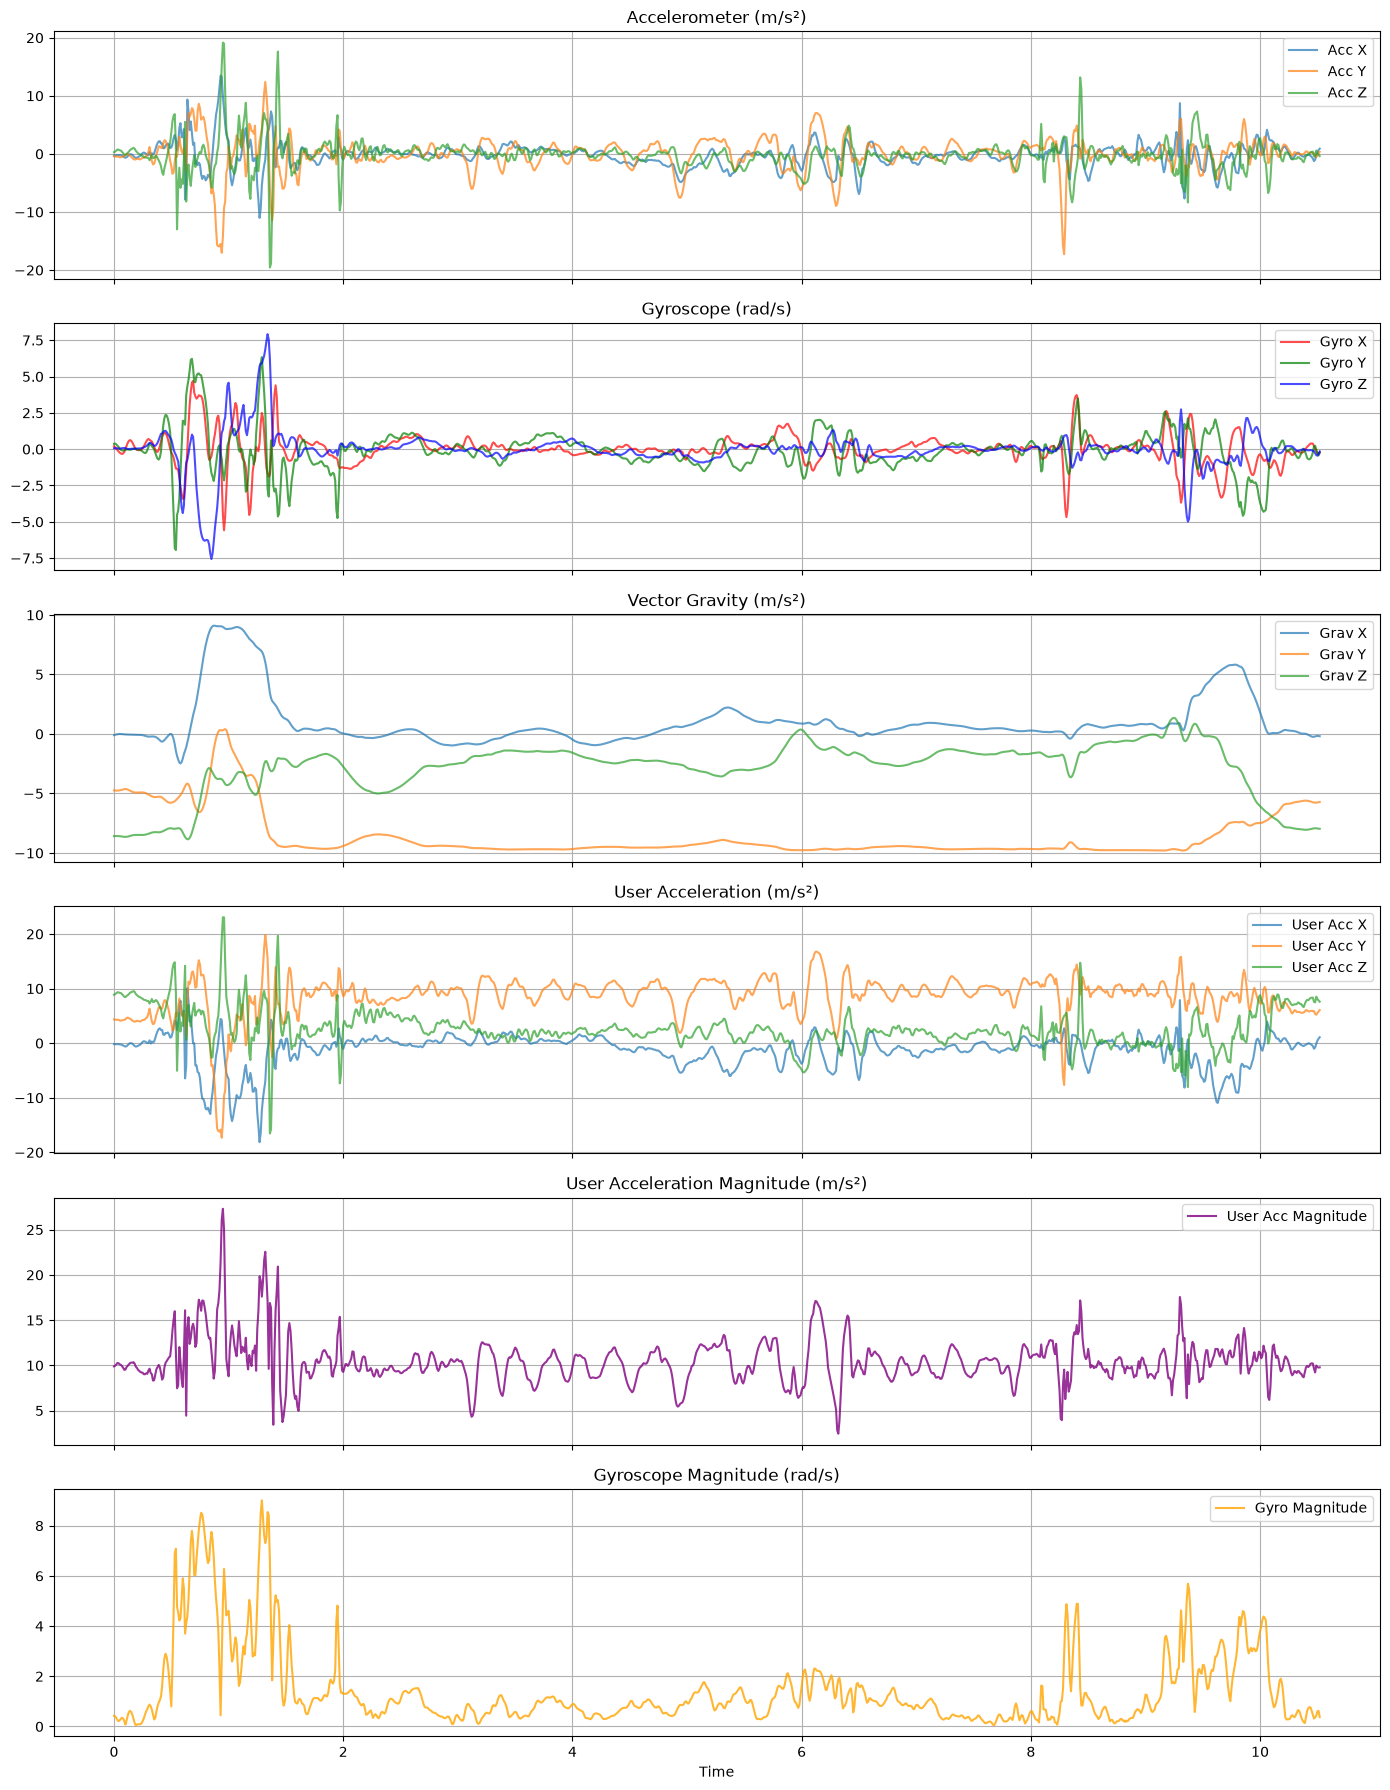

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

# Accelerometer
axes[0].plot(df_resampled['time_s'], df_resampled['acc_x'], label='Acc X', alpha=0.7)
axes[0].plot(df_resampled['time_s'], df_resampled['acc_y'], label='Acc Y', alpha=0.7)
axes[0].plot(df_resampled['time_s'], df_resampled['acc_z'], label='Acc Z', alpha=0.7)
axes[0].set_title('Accelerometer (m/s²)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Gyroscope
axes[1].plot(df_resampled['time_s'], df_resampled['gyro_x'], label='Gyro X', alpha=0.7, color='r')
axes[1].plot(df_resampled['time_s'], df_resampled['gyro_y'], label='Gyro Y', alpha=0.7, color='g')
axes[1].plot(df_resampled['time_s'], df_resampled['gyro_z'], label='Gyro Z', alpha=0.7, color='b')
axes[1].set_title('Gyroscope (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Gravity
axes[2].plot(df_resampled['time_s'], df_resampled['grav_x'], label='Grav X', alpha=0.7)
axes[2].plot(df_resampled['time_s'], df_resampled['grav_y'], label='Grav Y', alpha=0.7)
axes[2].plot(df_resampled['time_s'], df_resampled['grav_z'], label='Grav Z', alpha=0.7)
axes[2].set_title('Vector Gravity (m/s²)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

# User Acceleration (gravità sottratta)
axes[3].plot(df_resampled['time_s'], df_resampled['user_acc_x'], label='User Acc X', alpha=0.7)
axes[3].plot(df_resampled['time_s'], df_resampled['user_acc_y'], label='User Acc Y', alpha=0.7)
axes[3].plot(df_resampled['time_s'], df_resampled['user_acc_z'], label='User Acc Z', alpha=0.7)
axes[3].set_title('User Acceleration (m/s²)')
axes[3].legend(loc='upper right')
axes[3].grid(True)

# User Acc Magnitude
axes[4].plot(df_resampled['time_s'], df_resampled['user_acc_mag'], label='User Acc Magnitude', alpha=0.8, color='purple')
axes[4].set_title('User Acceleration Magnitude (m/s²)')
axes[4].legend(loc='upper right')
axes[4].grid(True)

# Gyro Magnitude
axes[5].plot(df_resampled['time_s'], df_resampled['gyro_mag'], label='Gyro Magnitude', alpha=0.8, color='orange')
axes[5].set_title('Gyroscope Magnitude (rad/s)')
axes[5].legend(loc='upper right')
axes[5].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

## Se the FFT before any filtering and trimming:

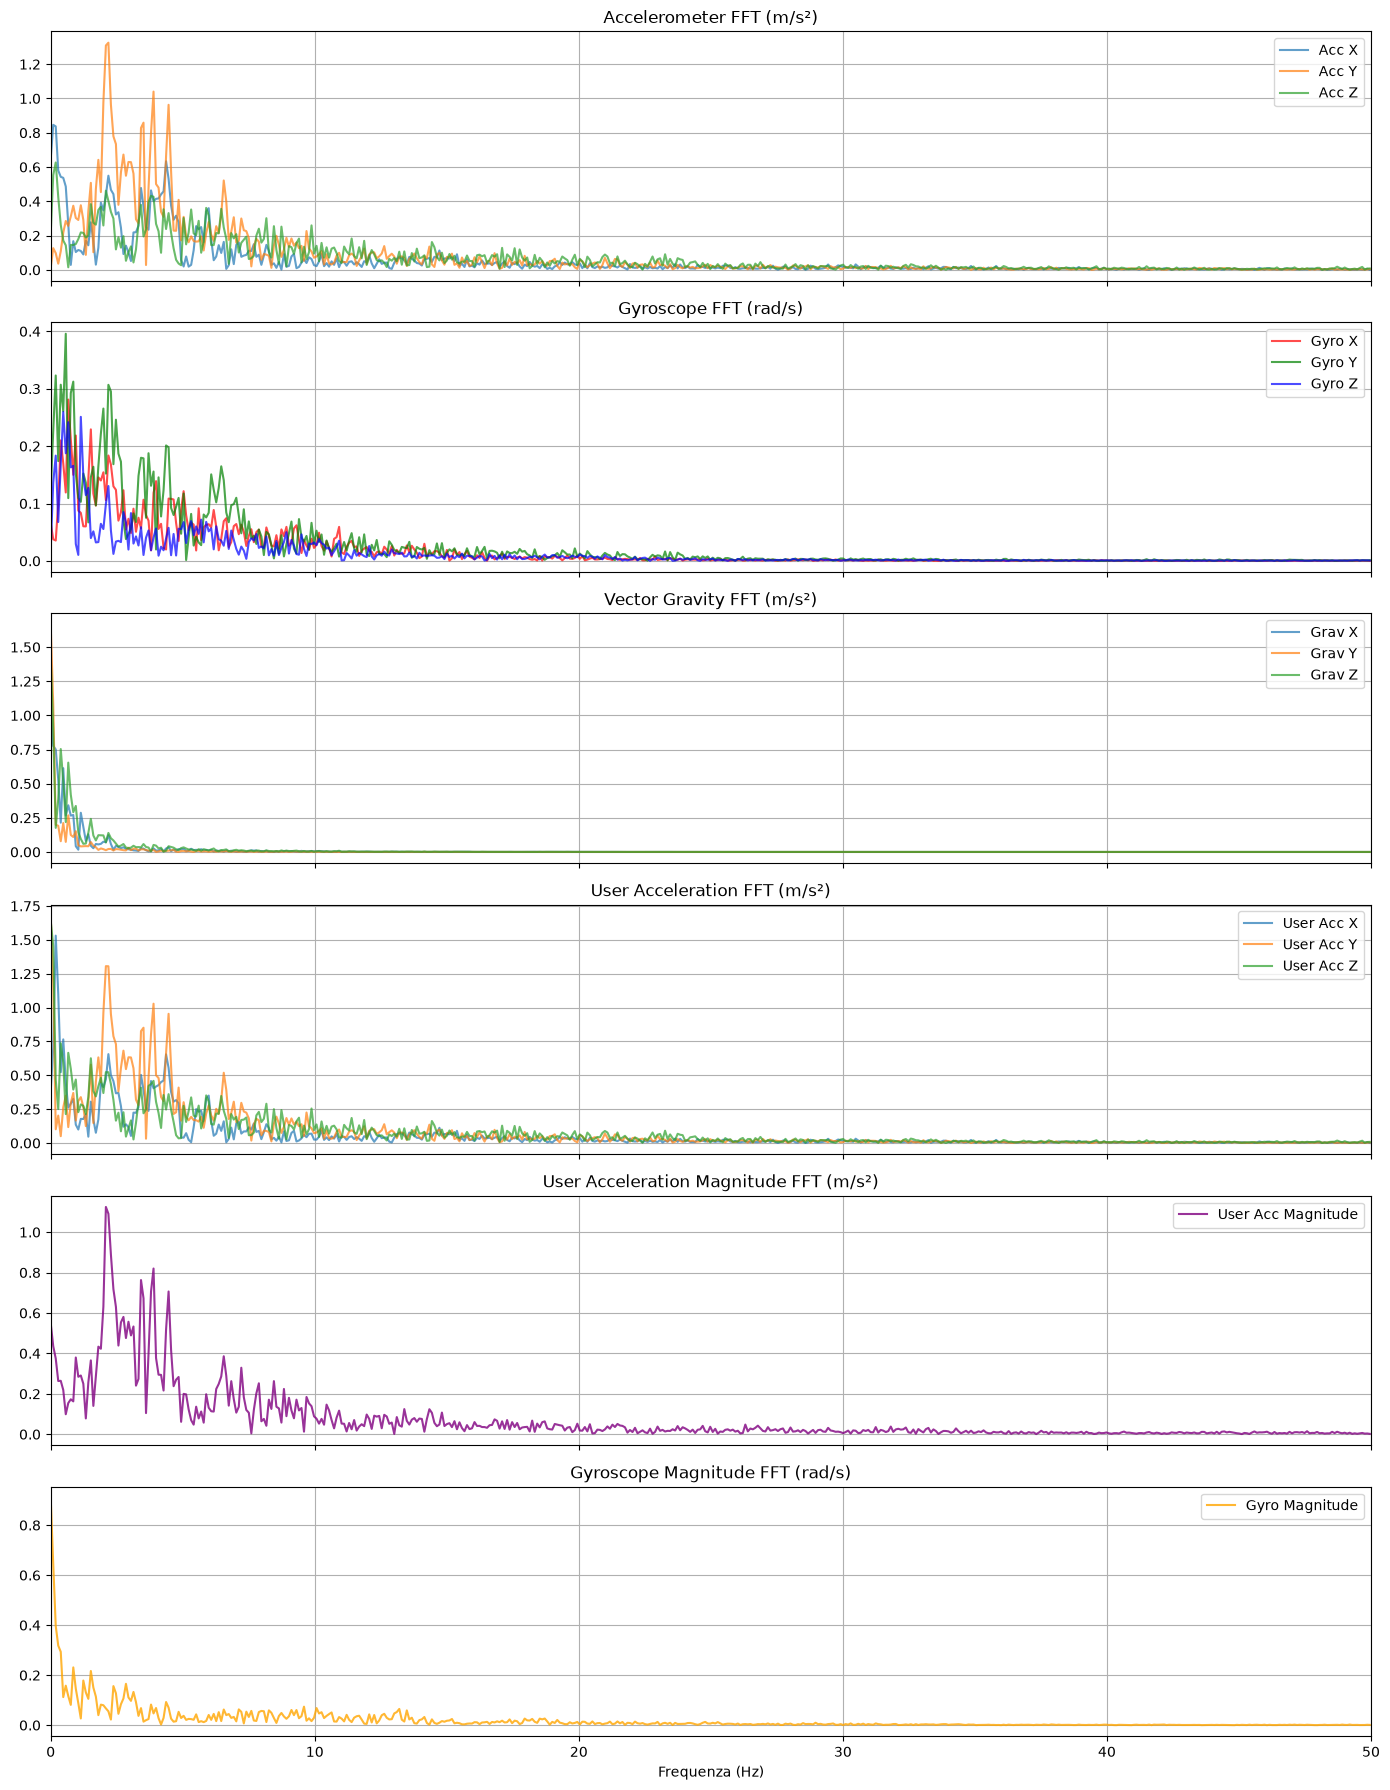

In [5]:
# --- Funzione FFT (rimuove DC + finestra di Hanning) ---
def compute_fft(signal, fs):
    n = len(signal)
    signal = signal - np.mean(signal)
    window = np.hanning(n)
    fft_vals = np.fft.rfft(signal * window)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    amplitude = np.abs(fft_vals) * 2 / np.sum(window)
    return freqs, amplitude

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

# Accelerometer
for col, label in [('acc_x', 'Acc X'), ('acc_y', 'Acc Y'), ('acc_z', 'Acc Z')]:
    freqs, amp = compute_fft(df_resampled[col].values, fs)
    axes[0].plot(freqs, amp, label=label, alpha=0.7)
axes[0].set_title('Accelerometer FFT (m/s²)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Gyroscope
colors = ['r', 'g', 'b']
for (col, label), c in zip([('gyro_x', 'Gyro X'), ('gyro_y', 'Gyro Y'), ('gyro_z', 'Gyro Z')], colors):
    freqs, amp = compute_fft(df_resampled[col].values, fs)
    axes[1].plot(freqs, amp, label=label, alpha=0.7, color=c)
axes[1].set_title('Gyroscope FFT (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Gravity
for col, label in [('grav_x', 'Grav X'), ('grav_y', 'Grav Y'), ('grav_z', 'Grav Z')]:
    freqs, amp = compute_fft(df_resampled[col].values, fs)
    axes[2].plot(freqs, amp, label=label, alpha=0.7)
axes[2].set_title('Vector Gravity FFT (m/s²)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

# User Acceleration (gravità sottratta)
for col, label in [('user_acc_x', 'User Acc X'), ('user_acc_y', 'User Acc Y'), ('user_acc_z', 'User Acc Z')]:
    freqs, amp = compute_fft(df_resampled[col].values, fs)
    axes[3].plot(freqs, amp, label=label, alpha=0.7)
axes[3].set_title('User Acceleration FFT (m/s²)')
axes[3].legend(loc='upper right')
axes[3].grid(True)

# User Acc Magnitude
freqs, amp = compute_fft(df_resampled['user_acc_mag'].values, fs)
axes[4].plot(freqs, amp, label='User Acc Magnitude', alpha=0.8, color='purple')
axes[4].set_title('User Acceleration Magnitude FFT (m/s²)')
axes[4].legend(loc='upper right')
axes[4].grid(True)

# Gyro Magnitude
freqs, amp = compute_fft(df_resampled['gyro_mag'].values, fs)
axes[5].plot(freqs, amp, label='Gyro Magnitude', alpha=0.8, color='orange')
axes[5].set_title('Gyroscope Magnitude FFT (rad/s)')
axes[5].legend(loc='upper right')
axes[5].grid(True)

plt.xlabel('Frequenza (Hz)')
# Opzionale: limita l'asse x se ti interessa solo la parte bassa dello spettro
axes[5].set_xlim(0, fs/2)

plt.tight_layout()
plt.show()

## We load the .parquet:
Now we apply a bandpass filter to ours signals for:
-   `lowcut = 5.0` Usefull to cut all the slow nois like padding;
-   `highcut = 30.0` Usefull to cut all the eletric noise;

In [ ]:
import pandas as pd
from scipy.signal import butter, filtfilt

fs = 100  # Sampling frequency in Hz

feature_cols = [
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'grav_x', 'grav_y', 'grav_z',
    'user_acc_x', 'user_acc_y', 'user_acc_z',
    'user_acc_mag', 'gyro_mag'
]

#Apply a bandpass filter to my sensor data to remove high-frequency noise
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band', analog=False)
    y = filtfilt(b, a, data)
    return y    

#Apply the bandpass filter to the accelerometer, gyroscope, and gravity data
lowcut = 5  # Low cutoff frequency in Hz
highcut = 30  # High cutoff frequency in Hz
for col in feature_cols:
    df_resampled[col] = butter_bandpass_filter(df_resampled[col], lowcut, highcut, fs)     
    

In [8]:
def trim_dataframe(df, trim_start_sec=0, trim_end_sec=0, fs=100.0):
    """
    Remove a specified number of seconds from the start and end of a Pandas DataFrame based on the sampling frequency.
    
    Parameters:
    - df: DataFrame di Pandas
    - trim_start_sec: seconds to trim from the start (s)
    - trim_end_sec: seconds to trim from the end (s)
    - fs: Sampling frequency in Hz (Default: 100 Hz)
    
    Returns:
    - Trimmed DataFrame with reset index.
    """
    # Seconds to samples conversion
    start_samples = int(trim_start_sec * fs)
    end_samples = int(trim_end_sec * fs)
    
    # Error handling:
    if start_samples + end_samples >= len(df):
        raise ValueError("The seconds to trim exceed the total duration of the file!")
    
    # Apply the slicing: from the initial samples to the end minus the final samples
    if end_samples > 0:
        df_trimmed = df.iloc[start_samples:-end_samples].copy()
    else:
        df_trimmed = df.iloc[start_samples:].copy()
        
    # Reset the index for convenience
    df_trimmed.reset_index(drop=True, inplace=True)
    
    return df_trimmed

# Trim data to remove the first 3 seconds and the last 2 seconds of the recording
df_trimmed = trim_dataframe(df, trim_start_sec=3.0, trim_end_sec=3.0, fs=100.0)

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_trimmed)}")

Rows before trimming: 1053
Rows after trimming: 453


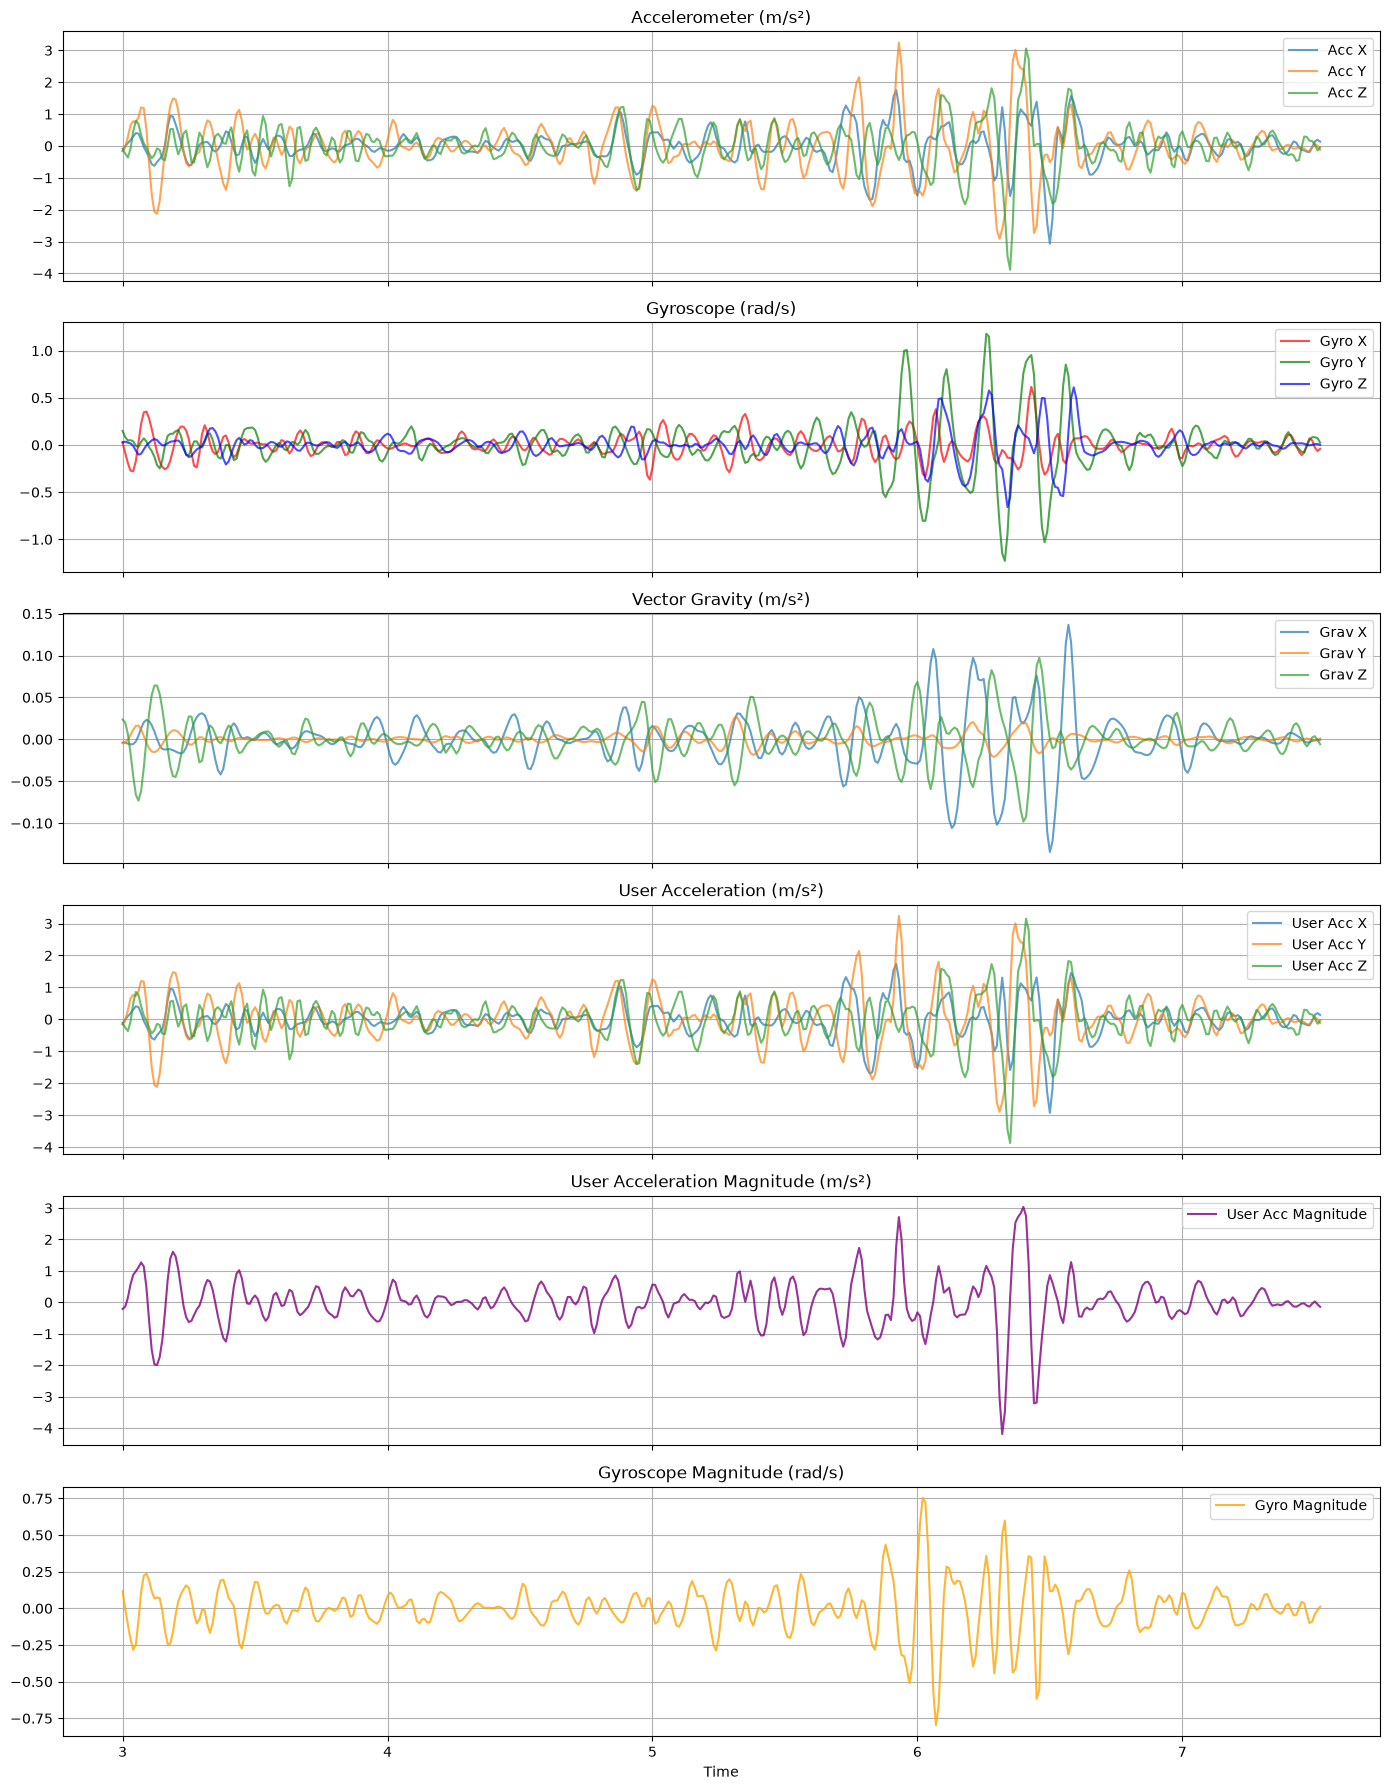

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)

# Accelerometer
axes[0].plot(df_trimmed['time_s'], df_trimmed['acc_x'], label='Acc X', alpha=0.7)
axes[0].plot(df_trimmed['time_s'], df_trimmed['acc_y'], label='Acc Y', alpha=0.7)
axes[0].plot(df_trimmed['time_s'], df_trimmed['acc_z'], label='Acc Z', alpha=0.7)
axes[0].set_title('Accelerometer (m/s²)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Gyroscope
axes[1].plot(df_trimmed['time_s'], df_trimmed['gyro_x'], label='Gyro X', alpha=0.7, color='r')
axes[1].plot(df_trimmed['time_s'], df_trimmed['gyro_y'], label='Gyro Y', alpha=0.7, color='g')
axes[1].plot(df_trimmed['time_s'], df_trimmed['gyro_z'], label='Gyro Z', alpha=0.7, color='b')
axes[1].set_title('Gyroscope (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Gravity
axes[2].plot(df_trimmed['time_s'], df_trimmed['grav_x'], label='Grav X', alpha=0.7)
axes[2].plot(df_trimmed['time_s'], df_trimmed['grav_y'], label='Grav Y', alpha=0.7)
axes[2].plot(df_trimmed['time_s'], df_trimmed['grav_z'], label='Grav Z', alpha=0.7)
axes[2].set_title('Vector Gravity (m/s²)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

# User Acceleration (gravità sottratta)
axes[3].plot(df_trimmed['time_s'], df_trimmed['user_acc_x'], label='User Acc X', alpha=0.7)
axes[3].plot(df_trimmed['time_s'], df_trimmed['user_acc_y'], label='User Acc Y', alpha=0.7)
axes[3].plot(df_trimmed['time_s'], df_trimmed['user_acc_z'], label='User Acc Z', alpha=0.7)
axes[3].set_title('User Acceleration (m/s²)')
axes[3].legend(loc='upper right')
axes[3].grid(True)

# User Acc Magnitude
axes[4].plot(df_trimmed['time_s'], df_trimmed['user_acc_mag'], label='User Acc Magnitude', alpha=0.8, color='purple')
axes[4].set_title('User Acceleration Magnitude (m/s²)')
axes[4].legend(loc='upper right')
axes[4].grid(True)

# Gyro Magnitude
axes[5].plot(df_trimmed['time_s'], df_trimmed['gyro_mag'], label='Gyro Magnitude', alpha=0.8, color='orange')
axes[5].set_title('Gyroscope Magnitude (rad/s)')
axes[5].legend(loc='upper right')
axes[5].grid(True)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

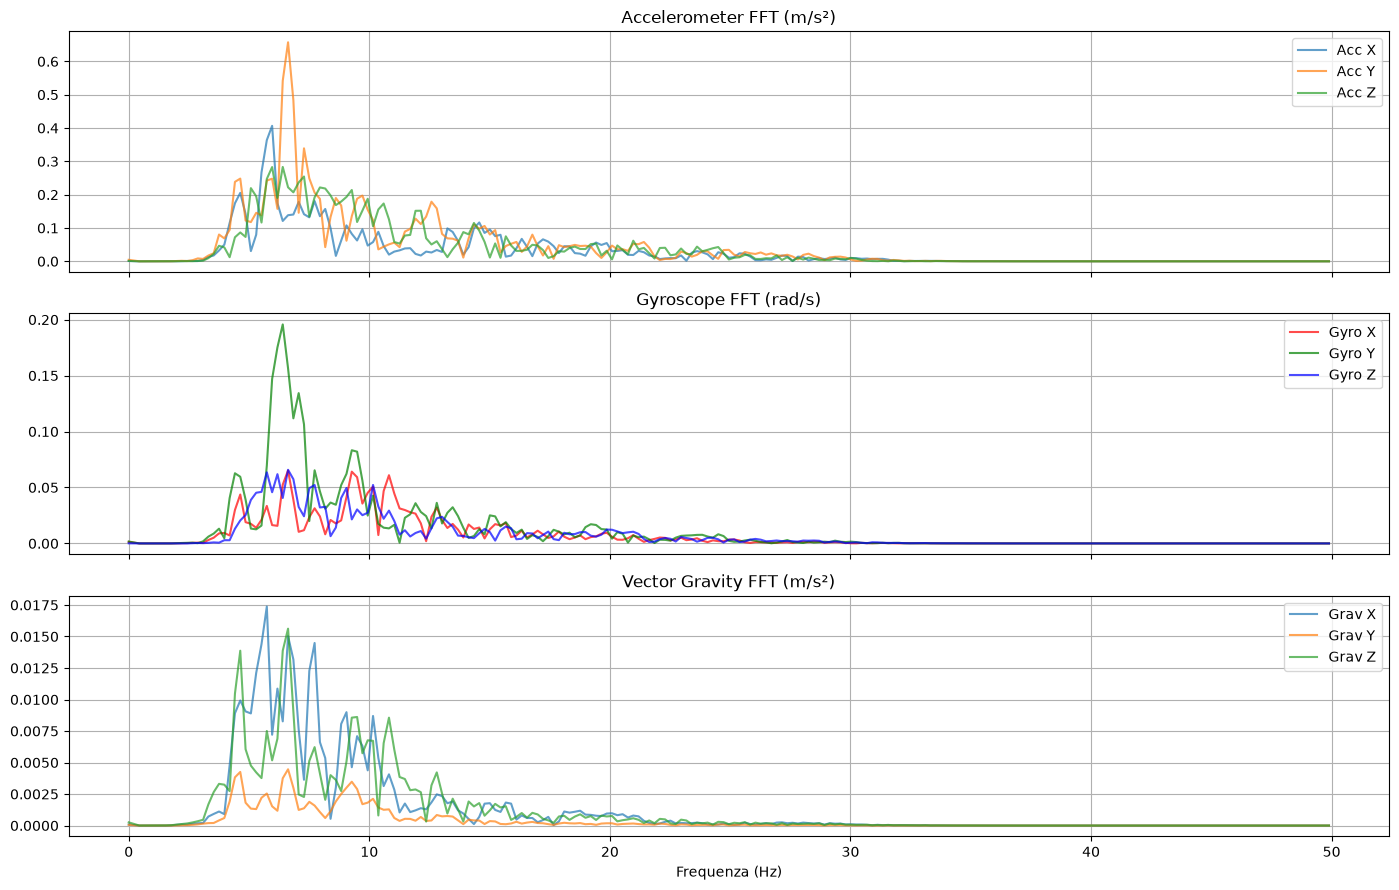

In [10]:
import numpy as np

# --- Funzione FFT (rimuove DC + finestra di Hanning) ---
def compute_fft(signal, fs):
    n = len(signal)
    signal = signal - np.mean(signal)
    window = np.hanning(n)
    fft_vals = np.fft.rfft(signal * window)
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    amplitude = np.abs(fft_vals) * 2 / np.sum(window)
    return freqs, amplitude

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Accelerometer
for col, label in [('acc_x', 'Acc X'), ('acc_y', 'Acc Y'), ('acc_z', 'Acc Z')]:
    freqs, amp = compute_fft(df_trimmed[col].values, fs)
    axes[0].plot(freqs, amp, label=label, alpha=0.7)
axes[0].set_title('Accelerometer FFT (m/s²)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Gyroscope
colors = ['r', 'g', 'b']
for (col, label), c in zip([('gyro_x', 'Gyro X'), ('gyro_y', 'Gyro Y'), ('gyro_z', 'Gyro Z')], colors):
    freqs, amp = compute_fft(df_trimmed[col].values, fs)
    axes[1].plot(freqs, amp, label=label, alpha=0.7, color=c)
axes[1].set_title('Gyroscope FFT (rad/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

# Gravity
for col, label in [('grav_x', 'Grav X'), ('grav_y', 'Grav Y'), ('grav_z', 'Grav Z')]:
    freqs, amp = compute_fft(df_trimmed[col].values, fs)
    axes[2].plot(freqs, amp, label=label, alpha=0.7)
axes[2].set_title('Vector Gravity FFT (m/s²)')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.xlabel('Frequenza (Hz)')
# Opzionale: limita l'asse x se ti interessa solo la parte bassa dello spettro
# axes[2].set_xlim(0, fs/2)

plt.tight_layout()
plt.show()

## LAST STEP: Save the processed data in a Parquet file:

In [11]:
# Save the processed DataFrame to a Parquet file for efficient storage and retrieval
#df_trimmed.to_parquet("session_01_processed.parquet", index=False)

### Feature Scaling Guide by Machine Learning Model
The scaling here is an Error, we must scale our data only when we have our entire data ready, here we are just preparing all the segment. We need to collect a series of section and later on concatenate them all together to have the entire data need to train and test.

## NO SCALING NEEDED IN THISC SECTION:
| Algorithm / Model | Recommended Scaler | Notes |
| :--- | :--- | :--- |
| **Unsupervised Clustering**<br>*(K-Means, DBSCAN)* | **StandardScaler** or **RobustScaler** | **Mandatory.** Distance-based metrics. Use *RobustScaler* if outliers exist. |
| **Anomaly Detection**<br>*(Isolation Forest, Autoencoder)* | **StandardScaler** or **MinMaxScaler** | Necessary to balance feature contributions and reconstruction errors. |
| **Deep Learning**<br>*(1D CNN, LSTM)* | **MinMaxScaler** *[-1, 1]* or **StandardScaler** | Ensures gradient stability and faster convergence during backpropagation. |
| **Traditional Supervised ML**<br>*(XGBoost, Random Forest)* | **Not required** *(Optional)* | Tree-based models split features individually, making them scale-invariant. |

In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler, PowerTransformer

# --- STEP 7 - FEATURE SCALING (TEMPORANEO, solo per questa sessione) ---
# NOTA: fittato solo su questa sessione perché è la prima che processi.
# Quando avrai tutte le sessioni unite, questo fit andrà rifatto sul
# training set completo (dopo lo split), non lasciato così.

scaler = StandardScaler()

df_scaled = df_trimmed.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_trimmed[feature_cols])

df_scaled.head()

,time_s,acc_z,acc_y,acc_x,gyro_z,gyro_y,gyro_x,grav_z,grav_y,grav_x,user_acc_x,user_acc_y,user_acc_z,user_acc_mag,gyro_mag,device_id,device_name
0,3.00,-0.131356,-0.198910,-0.309045,0.210648,0.547231,0.210819,0.985234,-0.736546,-0.126080,-0.306854,-0.193807,-0.166648,-0.285558,0.727112,2902d61d-d820-4893-92f7-4d834be6a862,iPhone 17
1,3.01,-0.366509,-0.056847,-0.005962,0.247197,0.304133,-0.668597,0.831665,-0.603282,-0.128964,0.001695,-0.052205,-0.394978,-0.183652,-0.013316,2902d61d-d820-4893-92f7-4d834be6a862,iPhone 17
2,3.02,-0.550890,0.364249,0.182719,0.184166,0.171934,-1.552585,0.262540,-0.068714,-0.170745,0.196185,0.366392,-0.557626,0.195574,-0.683299,2902d61d-d820-4893-92f7-4d834be6a862,iPhone 17
3,3.03,-0.132198,0.833560,0.352411,0.115340,0.188068,-2.197807,-0.685474,0.801729,-0.200513,0.370632,0.830693,-0.106487,0.772273,-1.285440,2902d61d-d820-4893-92f7-4d834be6a862,iPhone 17
4,3.04,0.688505,0.983641,0.572968,-0.059380,0.139225,-2.240171,-1.816903,1.800301,-0.187714,0.594270,0.973335,0.751280,1.172978,-1.728960,2902d61d-d820-4893-92f7-4d834be6a862,iPhone 17


## Window Overlap

The data collected from a single hole shows a spike that lasts approximately from 0.5 to 1 second. Based on this observation, a **window size of 1 second** and a **stride of 0.2 seconds** will be used.

With a sampling frequency of **100 Hz**, each window contains **100 samples**. A stride of 0.2 seconds corresponds to **20 samples**, meaning that each new window starts 20 samples after the previous one.

As a result, consecutive windows share **80 samples**, corresponding to an **80% overlap**.

The window parameters are defined as follows:

```python
window_size = 1.0  # seconds
stride = 0.2       # seconds
```


In [13]:
def create_windows(df, feature_cols, window_size, stride, session_id=None):
    """
    Segmenta un DataFrame in finestre sovrapposte (sliding window).

    Parametri:
    - df: DataFrame di una singola sessione (già preprocessato/scalato)
    - feature_cols: colonne da includere nelle finestre
    - window_size: numero di campioni per finestra
    - stride: passo tra una finestra e la successiva
    - session_id: opzionale, valore da associare a ogni finestra

    Ritorna:
    - X: array numpy di shape (n_windows, window_size, n_features)
    - window_meta: DataFrame con info per finestra
    """
    data = df[feature_cols].values
    n_samples = len(data)

    if n_samples < window_size:
        raise ValueError(f"Sessione troppo corta ({n_samples} campioni) per una finestra di {window_size}")

    starts = np.arange(0, n_samples - window_size + 1, stride)
    windows = np.stack([data[s:s + window_size] for s in starts])

    window_meta = pd.DataFrame({
        'start_idx': starts,
        'end_idx': starts + window_size,
        'session_id': session_id if session_id is not None else np.nan,
    })

    if 'time_s' in df.columns:
        window_meta['start_time_s'] = df['time_s'].values[starts]

    return windows, window_meta


# --- Parametri per rilevamento spike brevi (buche) ---
window_duration_s = 1.0
overlap_pct = 0.8

window_size = int(window_duration_s * fs)   # 100 campioni
stride = int(window_size * (1 - overlap_pct))            # 20 campioni

X, window_meta = create_windows(
    df_scaled,
    feature_cols=feature_cols,
    window_size=window_size,
    stride=stride,
    session_id=0
)

print(f"Shape finestre: {X.shape}")  # (n_windows, 100, 13)
print(f"Numero finestre generate: {len(window_meta)}")
window_meta.head()

Shape finestre: (19, 100, 14)
Numero finestre generate: 19


,start_idx,end_idx,session_id,start_time_s
0,0,100,0,3.00
1,19,119,0,3.19
2,38,138,0,3.38
3,57,157,0,3.57
4,76,176,0,3.76


## Feature Extraction per Window

Since I'm using a traditional machine learning model (Random Forest / XGBoost) rather than a deep learning approach (1D CNN / LSTM), I cannot feed the raw windowed sequences directly into the model. Traditional ML models expect a **flat feature vector per sample**, not a raw time-series sequence.

To address this, I extract a set of statistical features from each window, summarizing the signal's behavior over that time span:

- **Mean, Std, Min, Max**: general shape and dispersion of the signal
- **Peak-to-peak (ptp)** and **Absolute max**: useful for spike detection (e.g. pothole impacts)
- **RMS** and **Energy**: overall signal magnitude/intensity
- **Skewness** and **Kurtosis**: shape of the distribution (asymmetry, "peakedness")
- **Zero-crossing rate (ZCR)**: how often the signal oscillates around zero, useful for gyroscope channels

This transforms each window from shape `(window_size, n_channels)` into a single flat vector of `n_channels * n_stats` features, which is the format required by tree-based models.

In [14]:
from scipy.stats import skew, kurtosis

def extract_window_features(window, channel_names):
    """
    Estrae feature statistiche da una singola finestra.

    Parametri:
    - window: array numpy di shape (window_size, n_channels)
    - channel_names: nomi delle colonne, nello stesso ordine dei canali

    Ritorna: dict {nome_feature: valore}
    """
    features = {}

    for i, ch in enumerate(channel_names):
        signal = window[:, i]

        features[f'{ch}_mean'] = np.mean(signal)
        features[f'{ch}_std'] = np.std(signal)
        features[f'{ch}_min'] = np.min(signal)
        features[f'{ch}_max'] = np.max(signal)
        features[f'{ch}_ptp'] = np.ptp(signal)  # peak-to-peak (max - min)
        features[f'{ch}_rms'] = np.sqrt(np.mean(signal**2))
        features[f'{ch}_energy'] = np.sum(signal**2)
        features[f'{ch}_skew'] = skew(signal)
        features[f'{ch}_kurtosis'] = kurtosis(signal)
        features[f'{ch}_abs_max'] = np.max(np.abs(signal))  # utile per spike detection

        # Zero-crossing rate: quante volte il segnale cambia segno
        features[f'{ch}_zcr'] = np.sum(np.diff(np.sign(signal)) != 0)

    return features


def extract_features_from_windows(X, channel_names):
    """
    Applica extract_window_features a tutte le finestre.

    Parametri:
    - X: array numpy di shape (n_windows, window_size, n_channels)
    - channel_names: nomi delle colonne

    Ritorna: DataFrame (n_windows, n_features)
    """
    feature_rows = [extract_window_features(w, channel_names) for w in X]
    return pd.DataFrame(feature_rows)


# --- Applicazione ---
feature_cols = [
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'grav_x', 'grav_y', 'grav_z',
    'user_acc_x', 'user_acc_y', 'user_acc_z',
    'user_acc_mag', 'gyro_mag'
]

X_features = extract_features_from_windows(X, feature_cols)

# Riattacca i metadata (session_id, start_idx, ecc.) per riferimento
X_features = pd.concat([window_meta.reset_index(drop=True), X_features], axis=1)

print(f"Shape feature matrix: {X_features.shape}")  # (n_windows, n_meta_cols + 13*10)
X_features.head()

Shape feature matrix: (19, 158)


,start_idx,end_idx,session_id,start_time_s,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_ptp,acc_x_rms,...,gyro_mag_std,gyro_mag_min,gyro_mag_max,gyro_mag_ptp,gyro_mag_rms,gyro_mag_energy,gyro_mag_skew,gyro_mag_kurtosis,gyro_mag_abs_max,gyro_mag_zcr
0,0,100,0,3.00,0.000300,0.570425,-1.200570,1.818053,3.018622,0.570425,...,0.692485,-1.728960,1.458374,3.187335,0.692827,48.000989,-0.267648,-0.085758,1.728960,20
1,19,119,0,3.19,-0.013432,0.507181,-1.157382,1.771949,2.929330,0.507358,...,0.554849,-1.671938,1.208325,2.880262,0.554850,30.785860,-0.136727,0.209968,1.671938,19
2,38,138,0,3.38,0.006653,0.423405,-1.021482,0.889811,1.911292,0.423458,...,0.500851,-1.671938,1.208325,2.880262,0.500901,25.090153,-0.302660,0.896982,1.671938,18
3,57,157,0,3.57,-0.007969,0.396138,-0.897960,0.756710,1.654670,0.396219,...,0.392682,-0.638543,1.033949,1.672492,0.392819,15.430697,0.353750,-0.488147,1.033949,17
4,76,176,0,3.76,-0.002423,0.372665,-0.897960,0.724081,1.622041,0.372673,...,0.405485,-0.710572,1.033949,1.744521,0.405494,16.442524,0.180007,-0.710756,1.033949,17


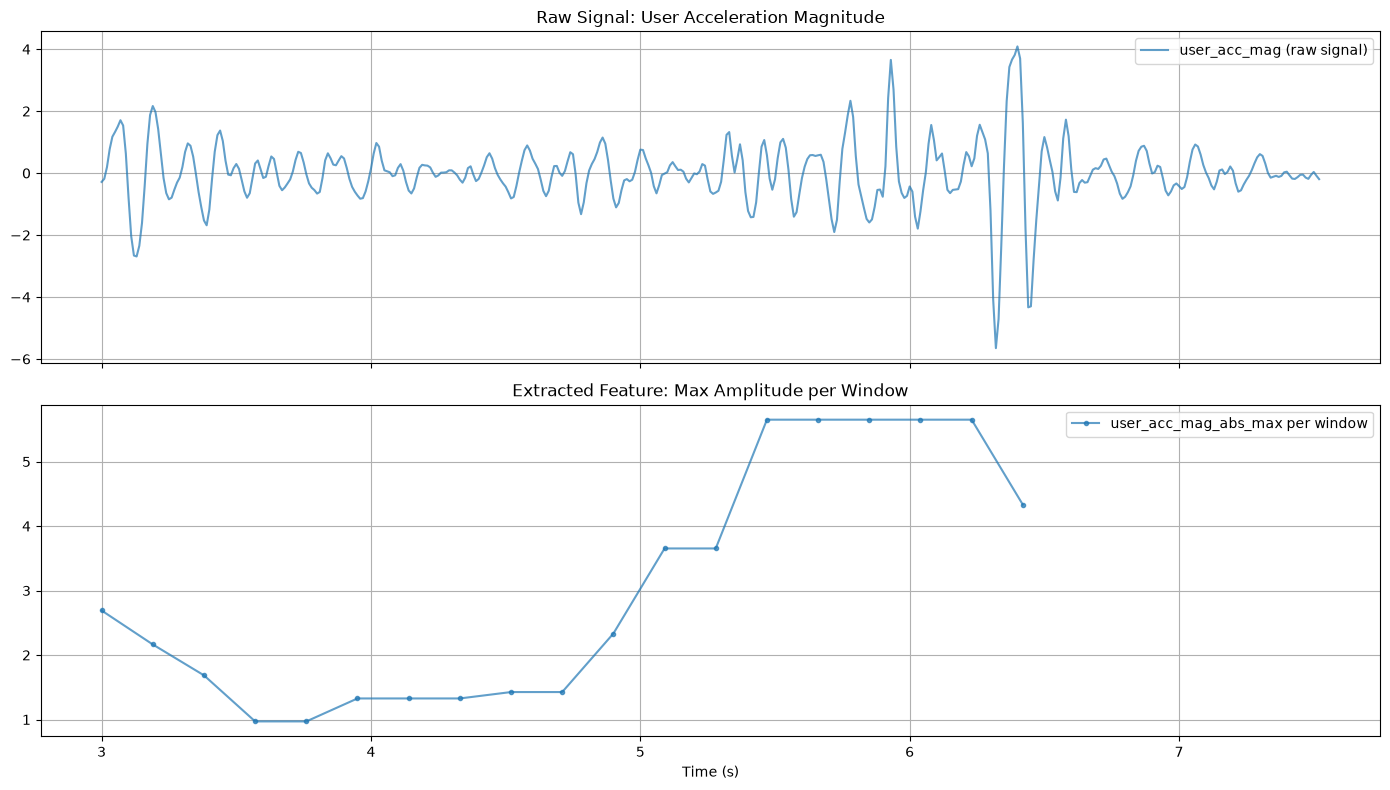

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Segnale grezzo di riferimento (quello che guardavi già per individuare le buche)
axes[0].plot(df_scaled['time_s'], df_scaled['user_acc_mag'], alpha=0.7, label='user_acc_mag (raw signal)')
axes[0].set_title('Raw Signal: User Acceleration Magnitude')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Feature estratta per finestra, plottata contro il tempo di inizio finestra
axes[1].plot(X_features['start_time_s'], X_features['user_acc_mag_abs_max'],
             marker='o', markersize=3, alpha=0.7, label='user_acc_mag_abs_max per window')
axes[1].set_title('Extracted Feature: Max Amplitude per Window')
axes[1].set_xlabel('Time (s)')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Maybe this Val for the mag abs max can be used a all the windows to laber where there is a hole or now